# The explicit dye: rotamer ensembles

The previous notebook put a dye on hGBP1 as an accessible volume: a cloud of
grid points a ball on a tether can reach, uniformly weighted, with no atoms and
no energies in it. This notebook puts the same dye on the same site as a
molecule.

The **explicit** route places a real, atomistic dye plus linker on the residue
in each conformer of a **rotamer library**, scores every conformer against the
protein with a Lennard-Jones (optionally Debye-Huckel) potential, and keeps the
Boltzmann weights of the survivors. What comes back carries the conformers'
atoms, their chromophore centres, their **transition dipoles**, their energies,
and the partition function. It costs a fraction of a second per site instead of
tens of milliseconds, and in exchange it can answer two questions the cloud
cannot: is this dye sticking, and what is kappa-squared here.

The plan: build the ensemble at one site, look hard at the two diagnostics that
decide whether it may be believed, compare it with the accessible volume at
several pairs, and then look at both in the browser -- the cloud and the
conformers it is supposed to be an envelope of, in one picture.

The site is the one notebook 3 worked on: donor Alexa488 on B496, acceptor
Alexa647 on B344, on frame 0 of hGBP1's recorded transition. Nothing is carried
over from that kernel; the two lines below rebuild it.

In [1]:
%matplotlib inline
import json
import pathlib
import sys
import time

import numpy as np
import matplotlib.pyplot as plt

here = pathlib.Path.cwd()
for candidate in (here, here / "doc" / "workshop", here.parent):
    if (candidate / "workshop.py").exists():
        sys.path.insert(0, str(candidate))
        break
import workshop as ws
import IMP.bff as bff

n_frames = ws.hgbp1_n_frames()
LAST = n_frames - 1
start = ws.hgbp1_state(0)                 # hGBP1, one end of the transition
DONOR = ("B", 496, "Alexa488")            # chain letters are residue ranges,
ACCEPTOR = ("B", 344, "Alexa647")         # not protein copies -- see notebook 3

av_donor = ws.av(start, *DONOR)           # the accessible volumes, rebuilt
av_acceptor = ws.av(start, *ACCEPTOR)     # so this notebook stands alone
print("structure: %s, %d frames recorded, this is frame 0" % (start.name, n_frames))
print("AV1 at %s%d: %d points ; at %s%d: %d points"
      % (DONOR[0], DONOR[1], av_donor.get_n_points(),
         ACCEPTOR[0], ACCEPTOR[1], av_acceptor.get_n_points()))
print("AV <R_DA>   %6.2f A" % ws.rda(av_donor, av_acceptor))
print("AV <R_DA>_E %6.2f A  (R0 = %.1f A)" % (ws.rda_e(av_donor, av_acceptor), ws.R0))

structure: hGBP1_frame000.pdb, 58 frames recorded, this is frame 0
AV1 at B496: 3670 points ; at B344: 3895 points
AV <R_DA>    48.49 A
AV <R_DA>_E  49.04 A  (R0 = 52.0 A)


## 1. The pieces

All of it is reachable as `IMP.bff.<Name>`:

* `IMP.bff.load_probe_rotamer_library(name)` -- a **rotamer library**: a fixed
  sample of conformers of the *free* dye plus linker, with populations. The
  bundled libraries are FRETpredict's, in `data/rotamer_library`; the name
  carries the dye, the linker chemistry (`C1R`, `C2R`, `L1R`) and the
  clustering cutoff.
* `IMP.bff.ProbeRotamerEnsemble.from_site(pdb, chain, residue, library, ...)`
  -- place that library on a site in the backbone frame of the residue and
  **screen** it against the protein.
* `ensemble.pair_distribution(other, R0)` -- the pair's FRET numbers:
  `<kappa^2>`, and E in the three averaging regimes.
* `ensemble.pair_geometry(other, use_dipoles)` -- the distances and weights
  themselves, with the option of forcing kappa-squared = 2/3 so the geometry can
  be compared with an AV on equal terms.
* `IMP.bff.FRETRotamer(...)` -- the same thing over a whole trajectory, with
  FRETpredict's parameter names, writing FRETpredict's output files.
* `IMP.bff.attach_probes` / `IMP.bff.ProbeAttachment` -- move an atomistic dye
  read from MOL2 or PDB onto a residue, when you want one explicit conformer in
  a model rather than an ensemble. (There is no `attach_dyes`; the function is
  `attach_probes`, and the whole layer is called `cgprobe`.)
* On the command line: `imp_bff dye sample-rotamer`, `imp_bff dye
  sample-langevin`, and `imp_bff av-vs-rotamer`, which records exactly the
  comparison this notebook makes into `okf/validation/av_vs_rotamer.md`.
* In the library: `IMP.bff.av_rotamer_case("hgbp1"|"t4l")` plus
  `compare_av_and_rotamer_positions` / `compare_av_and_rotamer_pairs` run that
  comparison on the two reference systems the package pins -- hGBP1 is one of
  them.

The bundled libraries ship with the module, so nothing is downloaded here. If
your installation is missing them, `IMP.bff.DATA_URL` and the
`imp_bff_fetch_data` entry point pull the data bundle; the cell below says
plainly which route it took.

In [2]:
registry = json.loads(bff.probe_rotamer_library_registry())
print(len(registry), "rotamer libraries in the registry")
print("the two this notebook uses:")
for dye in ("Alexa488", "Alexa647"):
    name = ws.rotamer_library_name(dye, cutoff=10)
    try:
        path = pathlib.Path(bff.resolve_probe_rotamer_library_path(name))
        library = bff.load_probe_rotamer_library(name)
        meta = json.loads(library.metadata)
        print("  %-9s -> %-28s %4d conformers, %d atoms; bundled at %s"
              % (dye, name, library.coords.shape[0], library.coords.shape[1], path.parent.name))
        print("              chromophore centre selector %r, dipole selector %r"
              % (meta.get("r"), meta.get("mu")))
    except Exception as error:
        print("  %-9s -> %s NOT AVAILABLE: %s" % (dye, name, error))
        print("              run `imp_bff_fetch_data` (downloads from IMP.bff.DATA_URL)")

34 rotamer libraries in the registry
the two this notebook uses:
  Alexa488  -> AlexaFluor 488 C1R cutoff10   711 conformers, 83 atoms; bundled at rotamer_library
              chromophore centre selector ['C7 and resname A48'], dipole selector ['C2', 'C13 and resname A48']
  Alexa647  -> AlexaFluor 647 C2R cutoff10   798 conformers, 122 atoms; bundled at rotamer_library
              chromophore centre selector ['C29 and resname A64'], dipole selector ['C4', 'C15 and resname A64']


## 2. Screening: Z and the effective sample size

Two numbers decide whether you may believe an ensemble.

**Z, the partition function**, is how much of the library's weight survives the
site. Z near 1 means the site barely obstructs the dye; Z above 1 means the
conformers are, on balance, finding attractive contacts. Z below
`IMP.bff.av_rotamer_z_cutoff()` (0.05) means essentially every conformer
clashes; the code then falls back to a uniform ensemble, and any number derived
from it describes the fallback, not the structure.

**The effective sample size** (`get_effective_sample_size`, Kish's
`(sum w)^2 / sum w^2`) is how many conformers the ensemble is *really*
carrying. This is the one people forget. The library is one fixed sample of the
free dye and a site only reweights it -- it never resamples. So a site can keep
a couple of hundred conformers and put three quarters of the weight on two of
them. Below roughly ten, the answer is a statement about the sample, not about
the site.

The cutoff in the library name sets how deep the sample is: `cutoff30` is 33
conformers for Alexa488 C1R, `cutoff10` is 711. Here is what that does at this
site pair.

In [3]:
ensembles = {}
print("cutoff   site   conformers      Z    effective sample size")
for cutoff in (30, 10):
    for chain, resi, dye in (DONOR, ACCEPTOR):
        e = bff.ProbeRotamerEnsemble.from_site(
            str(start), chain, resi, ws.rotamer_library_name(dye, cutoff),
            position_name="%s%d" % (chain, resi))
        ensembles[(cutoff, resi)] = e
        print("  %2d     %s%-4d %5d %-10s %6.3f   %8.1f"
              % (cutoff, chain, resi, e.get_n_rotamers(), "(%s)" % dye.replace("Alexa", "A"),
                 e.get_partition(), e.get_effective_sample_size()))
print()
print("z cutoff below which an ensemble is the uniform fallback:", bff.av_rotamer_z_cutoff())

cutoff   site   conformers      Z    effective sample size
  30     B496     33 (A488)      0.167        3.1
  30     B344    197 (A647)      0.271        4.1
  10     B496    711 (A488)      0.807      118.6
  10     B344    798 (A647)      0.348       33.0

z cutoff below which an ensemble is the uniform fallback: 0.05


This is the failure worth memorising, because it passes the test everybody
runs and fails the one nobody does. Both `cutoff30` ensembles are comfortably
above the Z cutoff -- 0.17 and 0.27, several times 0.05 -- so nothing in the
code complains. And both carry three to four effective conformers out of the 33
and 197 they nominally hold. Z says "this site does not destroy the dye". The
effective sample size says "and we are describing it with four conformers".

The `cutoff10` ensembles carry 119 and 33. The next cell shows what the
difference costs: the coarse library does not give a slightly noisier answer,
it gives a different one.

In [4]:
print("cutoff   <kappa^2>   E_static   E_dyn1   E_dyn2   R0 from spectra")
for cutoff in (30, 10):
    d, a = ensembles[(cutoff, DONOR[1])], ensembles[(cutoff, ACCEPTOR[1])]
    eff = d.pair_distribution(a, ws.R0)
    spec = d.pair_distribution_from_probes(a, "AlexaFluor 488", "AlexaFluor 647")
    print("  %2d      %7.3f    %7.4f  %7.4f  %7.4f   %7.2f A"
          % (cutoff, eff.kappa2_avg, eff.static_efficiency, eff.dynamic1,
             eff.dynamic2, spec.forster_radius))
print()
print("R0 for this pair at kappa^2 = 2/3, from the bundled spectra: %.2f A"
      % bff.forster_radius_from_spectra("AlexaFluor 488", "AlexaFluor 647",
                                        bff.kappa2_isotropic()))
print("R0 assumed by the AV route in notebook 3:                    %.2f A" % ws.R0)

cutoff   <kappa^2>   E_static   E_dyn1   E_dyn2   R0 from spectra
  30        0.324     0.3221   0.4440   0.4272     47.69 A
  10        0.604     0.5056   0.6462   0.8531     52.90 A

R0 for this pair at kappa^2 = 2/3, from the bundled spectra: 53.79 A
R0 assumed by the AV route in notebook 3:                    52.00 A


The `cutoff30` row is the lesson: `<kappa^2>` comes out at 0.32 rather than
0.60, and the efficiencies with it, entirely because four conformers between
the two sites are fixing the dipole directions. It is not a worse estimate, it
is an estimate of the wrong thing -- and note that its `<kappa^2>` also drags
the Forster radius the code derives from the spectra down by five Angstrom,
because R0 depends on kappa-squared. One diagnostic nobody printed has moved
every number on the row. Everything below uses `cutoff10`.

The three efficiencies are the three averaging regimes:

* **static** -- each donor-acceptor conformer pair is a separate molecule with
  its own rate; average the *efficiencies*. Right when the dyes are frozen on
  the lifetime timescale.
* **dynamic-1 / dynamic-2** -- the dyes interconvert fast; average the *rates*.
  Right when the dye reorients within the donor lifetime.

Real dyes on flexible linkers are usually closer to the dynamic limit, which is
also the limit the AV's `<R_DA>_E` corresponds to. The spread across the three
is not a rounding difference here, and the AV has no way to express it.

## 3. The two models side by side

To compare the geometry fairly, the rotamer pair is also evaluated with
`pair_geometry(other, use_dipoles=False)`, which forces kappa-squared = 2/3 --
the same assumption the AV makes. That isolates the question "do the two models
put the dye in the same place?" from the question "does orientation matter
here?".

In [5]:
d10 = ensembles[(10, DONOR[1])]
a10 = ensembles[(10, ACCEPTOR[1])]

# rotamer geometry with the AV's own kappa^2 = 2/3 assumption
geom = d10.pair_geometry(a10, False)
R_rot = np.asarray(geom.R)
w_rot = np.asarray(geom.weight)
w_rot = w_rot / w_rot.sum()
mean_rot = float((R_rot * w_rot).sum())
sigma_rot = float(np.sqrt((w_rot * (R_rot - mean_rot) ** 2).sum()))
E_rot_iso = float((w_rot / (1.0 + (R_rot / ws.R0) ** 6)).sum())
rdae_rot = ws.R0 * (1.0 / E_rot_iso - 1.0) ** (1.0 / 6.0)

axis, p_av = ws.distance_distribution(av_donor, av_acceptor)
p_av = p_av / p_av.sum()
mean_av = ws.rda(av_donor, av_acceptor)
sigma_av = float(np.sqrt((p_av * (axis - float((axis * p_av).sum())) ** 2).sum()))
rdae_av = ws.rda_e(av_donor, av_acceptor)
E_av = ws.efficiency(rdae_av)

eff10 = d10.pair_distribution(a10, ws.R0)

table = [
    ("donor x acceptor pairs", "%d" % (av_donor.get_n_points() * av_acceptor.get_n_points()),
                               "%d" % R_rot.size),
    ("<R_DA>  (A)",          "%.2f" % mean_av,    "%.2f" % mean_rot),
    ("sigma_R (A)",          "%.2f" % sigma_av,   "%.2f" % sigma_rot),
    ("<R_DA>_E (A), k2=2/3", "%.2f" % rdae_av,    "%.2f" % rdae_rot),
    ("<E>, k2=2/3",          "%.4f" % E_av,       "%.4f" % E_rot_iso),
    ("<kappa^2>",            "2/3 (assumed)",     "%.3f" % eff10.kappa2_avg),
    ("<E>, own kappa^2",     "not available",     "%.4f (dynamic-1)" % eff10.dynamic1),
    ("E static / dyn1 / dyn2", "one number only",
                             "%.3f / %.3f / %.3f" % (eff10.static_efficiency,
                                                     eff10.dynamic1, eff10.dynamic2)),
    ("site is believable?",  "%d and %d points" % (av_donor.get_n_points(),
                                                   av_acceptor.get_n_points()),
                             "ESS %.0f and %.0f, Z %.2f and %.2f"
                             % (d10.get_effective_sample_size(), a10.get_effective_sample_size(),
                                d10.get_partition(), a10.get_partition())),
]
width = max(len(r[0]) for r in table)
print("%-*s  %-24s  %s" % (width, "", "accessible volume (AV1)", "rotamer ensemble (cutoff10)"))
print("-" * (width + 55))
for label, left, right in table:
    print("%-*s  %-24s  %s" % (width, label, left, right))
print()
print("difference in <R_DA>_E at k2=2/3: %+.2f A, which is %+.3f in E"
      % (rdae_rot - rdae_av, E_rot_iso - E_av))

                        accessible volume (AV1)   rotamer ensemble (cutoff10)
-----------------------------------------------------------------------------
donor x acceptor pairs  14294650                  567378
<R_DA>  (A)             48.49                     45.43
sigma_R (A)             9.84                      8.25
<R_DA>_E (A), k2=2/3    49.04                     46.39
<E>, k2=2/3             0.5871                    0.6648
<kappa^2>               2/3 (assumed)             0.604
<E>, own kappa^2        not available             0.6462 (dynamic-1)
E static / dyn1 / dyn2  one number only           0.506 / 0.646 / 0.853
site is believable?     3670 and 3895 points      ESS 119 and 33, Z 0.81 and 0.35

difference in <R_DA>_E at k2=2/3: -2.65 A, which is +0.078 in E


Read that table carefully, because the headline is not "the models disagree".

**On geometry they nearly agree here.** With kappa-squared held at 2/3 for
both, the two `<R_DA>_E` values are 2.65 A apart. That is inside the error bar
of most of the measured hGBP1 distances the package ships, and outside a few of
them -- so at this site the choice of label model is a real but not dominant
term. It is also the best case: both sites are exposed, both ensembles are
thick, and there is no reason for the two models to disagree. Section 4 checks
what happens at sites with less going for them.

**On width they do not agree.** The AV distribution is the broader of the two:
the AV fills everything reachable and weights it uniformly, while the screened
library keeps the conformers that are energetically reasonable, and those sit in
a narrower band. A model that uses the *width* of p(R_DA) -- fitting a distance
distribution to a lifetime decay, say -- is using a number the AV is not
entitled to.

**On orientation the AV is silent.** `<kappa^2>` comes out at 0.60 rather than
0.667 here, close enough to change little; at a site where the dye is pinned it
will not be. Only the explicit route can tell you which case you are in, and
only it can separate the static from the dynamic limit -- the spread across the
three regimes on this one pair is a real systematic that a single AV number
cannot express.

## 4. Is that agreement a fluke of this site?

One site proves nothing. The cell below repeats both models at ten pairs built
from the published hGBP1 labelling positions, and flags the ones where the
rotamer ensemble is too thin to trust. The flag is not decoration: read the
table with the flagged rows covered up first, then uncover them.

In [6]:
chain_of = lambda resi: "A" if resi <= 151 else "B"
PAIRS = [(496, 254), (496, 344), (496, 540), (525, 254), (525, 344),
         (525, 496), (525, 540), (18, 344), (344, 496), (481, 540)]

cache = {}
def ensemble(resi, dye):
    if (resi, dye) not in cache:
        cache[(resi, dye)] = bff.ProbeRotamerEnsemble.from_site(
            str(start), chain_of(resi), resi, ws.rotamer_library_name(dye, 10))
    return cache[(resi, dye)]

t0 = time.time()
print("pair        AV <R_DA>_E   AV <E>   rot <R_DA>_E   rot <E>  d(R)    <k2>   ESS D/A")
results = []
for donor_resi, acceptor_resi in PAIRS:
    d_av = ws.av(start, chain_of(donor_resi), donor_resi, "Alexa488")
    a_av = ws.av(start, chain_of(acceptor_resi), acceptor_resi, "Alexa647")
    r_av = ws.rda_e(d_av, a_av)

    d_rot = ensemble(donor_resi, "Alexa488")
    a_rot = ensemble(acceptor_resi, "Alexa647")
    g = d_rot.pair_geometry(a_rot, False)
    R = np.asarray(g.R)
    w = np.asarray(g.weight)
    w = w / w.sum()
    E = float((w / (1.0 + (R / ws.R0) ** 6)).sum())
    r_rot = ws.R0 * (1.0 / E - 1.0) ** (1.0 / 6.0)
    k2 = d_rot.pair_distribution(a_rot, ws.R0).kappa2_avg
    ess_d, ess_a = d_rot.get_effective_sample_size(), a_rot.get_effective_sample_size()
    thin = min(ess_d, ess_a) < 10
    results.append((donor_resi, acceptor_resi, r_av, r_rot, thin))
    print("%s%d-%s%-4d %8.2f %8.3f %13.2f %8.3f %6.2f %7.3f  %4.0f/%-4.0f%s"
          % (chain_of(donor_resi), donor_resi, chain_of(acceptor_resi), acceptor_resi,
             r_av, ws.efficiency(r_av), r_rot, E, r_rot - r_av, k2,
             ess_d, ess_a, "   <- thin sample, do not trust" if thin else ""))
print("\n%d pairs in %.1f s" % (len(PAIRS), time.time() - t0))

trusted = [r for r in results if not r[4]]
flagged = [r for r in results if r[4]]
for name, group in (("trusted", trusted), ("flagged", flagged)):
    if not group:
        continue
    diffs = np.array([r[3] - r[2] for r in group])
    print("%s pairs (%d): rotamer shorter in %d, longer in %d; "
          "|difference| from %.2f to %.2f A"
          % (name, len(group), int((diffs < 0).sum()), int((diffs > 0).sum()),
             np.abs(diffs).min(), np.abs(diffs).max()))

pair        AV <R_DA>_E   AV <E>   rot <R_DA>_E   rot <E>  d(R)    <k2>   ESS D/A


B496-B254     78.10    0.080         81.80    0.062   3.70   0.704   119/28  


B496-B344     49.04    0.587         46.39    0.665  -2.65   0.604   119/33  


B496-B540     67.07    0.178         66.99    0.180  -0.08   0.787   119/64  
B525-B254     60.97    0.278         63.88    0.225   2.91   0.591    64/28  


B525-B344     50.48    0.544         46.87    0.651  -3.61   0.744    64/33  


B525-B496     49.51    0.573         47.90    0.621  -1.61   0.804    64/54  
B525-B540     35.91    0.902         32.36    0.945  -3.55   0.643    64/64  


A18-B344     45.84    0.681         49.51    0.573   3.67   0.779     3/33     <- thin sample, do not trust
B344-B496     49.18    0.583         41.89    0.785  -7.28   0.523     2/54     <- thin sample, do not trust


B481-B540     85.07    0.050         92.85    0.030   7.78   0.606     8/64     <- thin sample, do not trust

10 pairs in 2.0 s
trusted pairs (7): rotamer shorter in 5, longer in 2; |difference| from 0.08 to 3.70 A
flagged pairs (3): rotamer shorter in 1, longer in 2; |difference| from 3.67 to 7.78 A


Two things come out of this table, and the second one is the more useful.

**The disagreement is bounded, and it has no sign.** Across the seven pairs
whose ensembles are thick enough to believe, the rotamer answer is shorter at
five and longer at two, and the largest gap is under four Angstrom. There is no
"the explicit dye always comes out shorter" rule to apply here. The two models
are measuring the same geometry with different assumptions, and on an exposed,
well-sampled site the assumptions mostly cancel.

That is worth stating plainly because the opposite result is easy to produce. On
a structure whose labelling sites are blocked on one side, the AV's uniform
filling puts weight far out in the solvent on the open side and the screened
ensemble does not follow it; the rotamer answer then comes out shorter at every
pair, with a clear sign and a much larger spread. Which behaviour you get is a
property of the *sites*, not of the two methods, and the only way to know which
one you are in is to run both.

**The two largest gaps in the table are both in flagged rows.** Every flagged
row is an artefact of a handful of conformers rather than a statement about the
structure. Average them in with the rest and you will conclude that the two
label models disagree by seven or eight Angstrom on hGBP1, when what you have
measured is the effective sample size of a library.

Nothing here is tuned; these are the numbers the two calls return.

## 5. See both of them

This is the picture the notebook exists for. The cloud has no atoms and no
energies; the conformers are a real dye on a real linker, each one scored
against the protein. Three panels:

1. the AV1 cloud at the donor site, alone -- the geometric model;
2. the twelve heaviest-weighted conformers of the screened Alexa488 C1R
   ensemble, drawn as molecules, inside the same translucent cloud;
3. the donor cloud and its conformers together with the acceptor cloud and
   its conformers, the whole pair, turning on its own.

The viewer loads Mol* from a CDN, so these cells need internet access from your
**browser**. Every number above is already computed and unaffected if they do
not load.

In [7]:
protein = ws.protein_for_view(start)
donor_cloud = dict(pdb=ws.av_pdb(av_donor, max_points=900),
                   colour=ws.DONOR_COLOUR, label="AV1 B496")
donor_dyes = dict(pdb=ws.rotamer_pdb(d10, n_rotamers=12), colour=0xE0A020,
                  label="12 heaviest Alexa488 rotamers", style="ball-and-stick")

ws.show([
    {"title": "B496: the accessible volume alone",
     "structure": protein, "clouds": [donor_cloud]},
    {"title": "B496: the explicit dye inside the same volume",
     "structure": protein, "clouds": [donor_cloud, donor_dyes]},
], height=470)

In [8]:
acceptor_cloud = dict(pdb=ws.av_pdb(av_acceptor, max_points=900),
                      colour=ws.ACCEPTOR_COLOUR, label="AV1 B344")
acceptor_dyes = dict(pdb=ws.rotamer_pdb(a10, n_rotamers=12), colour=0x8E44AD,
                     label="12 heaviest Alexa647 rotamers", style="ball-and-stick")

ws.show([
    {"title": "the whole pair: both clouds, both sets of conformers (camera spinning)",
     "structure": protein, "spin": True,
     "clouds": [donor_cloud, donor_dyes, acceptor_cloud, acceptor_dyes]},
], height=520)

The conformers sit inside the clouds and fill only part of them. The cloud is
the envelope, and it is a *generous* envelope, which is why its distance
distribution came out the wider of the two. The next cell puts a number on
"inside".

In [9]:
# How far the rotamer chromophore centres sit from the AV cloud's own points.
for label, volume, ens in (("B496 donor", av_donor, d10),
                           ("B344 acceptor", av_acceptor, a10)):
    av_xyz = ws.av_points(volume)[:, :3]
    centres = np.asarray(ens.get_centres()).reshape(-1, 3)
    weights = np.asarray(ens.get_weights())
    keep = weights > 0
    distances = np.array([np.linalg.norm(av_xyz - c, axis=1).min() for c in centres[keep]])
    w = weights[keep] / weights[keep].sum()
    print("%s: %d of %d rotamers carry weight" % (label, int(keep.sum()), ens.get_n_rotamers()))
    print("   distance from a chromophore centre to the nearest AV grid point")
    print("   (grid spacing 1.5 A, so <= 1.5 A means 'inside the cloud'):")
    print("     weighted mean                    %5.2f A" % float((distances * w).sum()))
    print("     weight within 1.5 A of the cloud %5.3f" % float(w[distances <= 1.5].sum()))
    print("     weight further than 3 A out      %5.3f" % float(w[distances > 3.0].sum()))
    print("     furthest chromophore centre      %5.2f A outside" % float(distances.max()))

B496 donor: 342 of 711 rotamers carry weight
   distance from a chromophore centre to the nearest AV grid point
   (grid spacing 1.5 A, so <= 1.5 A means 'inside the cloud'):
     weighted mean                     1.07 A
     weight within 1.5 A of the cloud 0.866
     weight further than 3 A out      0.050
     furthest chromophore centre       6.41 A outside
B344 acceptor: 148 of 798 rotamers carry weight
   distance from a chromophore centre to the nearest AV grid point
   (grid spacing 1.5 A, so <= 1.5 A means 'inside the cloud'):
     weighted mean                     0.93 A
     weight within 1.5 A of the cloud 0.815
     weight further than 3 A out      0.000
     furthest chromophore centre       3.38 A outside


Most of each ensemble's weight sits within one grid spacing of its cloud: as a
container, the AV is doing its job. The remainder says the containment is not
exact in either direction -- a little weight reaches places the AV's 3.5 A dye
radius and 4.5 A linker width say the dye cannot go, because the real linker is
thinner and bends differently than the search assumes.

Containment being good is not the same as the two distributions being the same.
The cloud contains the conformers and then keeps going, and "generous" is a
systematic error, not a random one.

## 6. An ensemble belongs to a structure, not to a site

One more thing the explicit route makes visible, and the reason this workshop
uses a trajectory rather than a single structure. The screening is done against
the protein *as it is in that frame*. Move the protein and the surviving
conformers change, which means Z, the effective sample size and kappa-squared
are all properties of a structure-and-site pair, not of the site.

Watch the transition, then look at what it does to the donor ensemble.

In [10]:
frames = ws.hgbp1_frames(every=6)
ws.show([{"title": "hGBP1: the recorded transition the ensembles are screened against",
          "structure": ws.morph_pdb(frames), "animate_models": True,
          "frame_ms": 320, "clouds": []}], height=420)

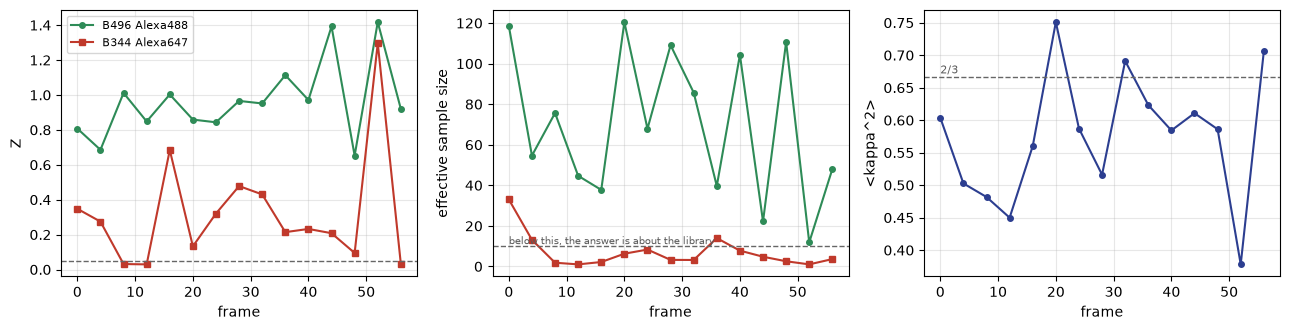

15 frames screened in 6.4 s
Z   ranges 0.65-1.42 (donor) and 0.03-1.30 (acceptor)
ESS ranges 12-120 (donor) and 1-33 (acceptor)
<kappa^2> ranges 0.378-0.751 over the path
rotamer <R_DA>_E (k2 = 2/3) ranges 28.72-50.43 A


In [11]:
t0 = time.time()
sampled = list(range(0, n_frames, 4))
z_track, ess_track, k2_track, rdae_track = [], [], [], []
for f in sampled:
    pdb = ws.hgbp1_state(f)
    d = bff.ProbeRotamerEnsemble.from_site(
        str(pdb), DONOR[0], DONOR[1], ws.rotamer_library_name("Alexa488", 10))
    a = bff.ProbeRotamerEnsemble.from_site(
        str(pdb), ACCEPTOR[0], ACCEPTOR[1], ws.rotamer_library_name("Alexa647", 10))
    g = d.pair_geometry(a, False)
    R, w = np.asarray(g.R), np.asarray(g.weight)
    w = w / w.sum()
    E = float((w / (1.0 + (R / ws.R0) ** 6)).sum())
    z_track.append((d.get_partition(), a.get_partition()))
    ess_track.append((d.get_effective_sample_size(), a.get_effective_sample_size()))
    k2_track.append(d.pair_distribution(a, ws.R0).kappa2_avg)
    rdae_track.append(ws.R0 * (1.0 / E - 1.0) ** (1.0 / 6.0))
z_track = np.asarray(z_track); ess_track = np.asarray(ess_track)

fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.4))
for ax, data, name in ((axes[0], z_track, "Z"),
                       (axes[1], ess_track, "effective sample size")):
    ax.plot(sampled, data[:, 0], "o-", ms=4, color="#2E8B57", label="B496 Alexa488")
    ax.plot(sampled, data[:, 1], "s-", ms=4, color="#C0392B", label="B344 Alexa647")
    ax.set_xlabel("frame"); ax.set_ylabel(name); ax.grid(alpha=0.3)
axes[1].axhline(10, color="0.4", lw=1.0, ls="--")
axes[1].annotate("below this, the answer is about the library", (0, 11),
                 fontsize=7.5, color="0.35")
axes[0].axhline(bff.av_rotamer_z_cutoff(), color="0.4", lw=1.0, ls="--")
axes[0].legend(fontsize=8)
axes[2].plot(sampled, k2_track, "o-", ms=4, color="#2C3E90")
axes[2].axhline(2.0 / 3.0, color="0.4", lw=1.0, ls="--")
axes[2].annotate("2/3", (0, 0.672), fontsize=8, color="0.35")
axes[2].set_xlabel("frame"); axes[2].set_ylabel("<kappa^2>"); axes[2].grid(alpha=0.3)
fig.tight_layout()
plt.show()

print("%d frames screened in %.1f s" % (len(sampled), time.time() - t0))
print("Z   ranges %.2f-%.2f (donor) and %.2f-%.2f (acceptor)"
      % (z_track[:, 0].min(), z_track[:, 0].max(), z_track[:, 1].min(), z_track[:, 1].max()))
print("ESS ranges %.0f-%.0f (donor) and %.0f-%.0f (acceptor)"
      % (ess_track[:, 0].min(), ess_track[:, 0].max(),
         ess_track[:, 1].min(), ess_track[:, 1].max()))
print("<kappa^2> ranges %.3f-%.3f over the path" % (min(k2_track), max(k2_track)))
print("rotamer <R_DA>_E (k2 = 2/3) ranges %.2f-%.2f A"
      % (min(rdae_track), max(rdae_track)))

Three readings, and none of them is available from a single structure.

**Z moves, and at the acceptor it crosses the line.** The donor site stays
comfortable along the whole path. The acceptor site does not: its partition
function falls to 0.03 at some frames, below the 0.05 cutoff, which means the
ensemble there is the uniform fallback and the numbers computed from it describe
the fallback. On those frames B344 has no usable explicit answer at all.

**The effective sample size moves with it**, from 33 down to 1 at the acceptor.
The site that looked thick enough to trust in section 3 is thick enough on
*frame 0*. A pipeline that screens one structure, records the ESS once, and
then reuses the ensemble across a trajectory is recording a diagnostic that has
since expired.

**And kappa-squared is not 2/3 anywhere in particular.** It ranges from 0.38 to
0.75 along the path -- straddling 2/3, but never sitting on it, and moving by
more than the difference between the two label models at this pair. An
orientation-factor error budget taken from one frame is a budget for one frame.

The AV has none of these problems, because it has none of this information. The
cloud is the same shape whatever the dye would have felt there. That is the
trade in one sentence.

## 7. Which model to use

**Use the accessible volume when** you are placing many labels, screening many
site pairs, or driving a structural model with FRET restraints. It is fast
enough to sit inside an optimiser, it needs nothing but the structure and four
numbers per dye, and at an open site it agrees with the explicit dye to within a
few Angstrom -- often within the measurement. Almost all integrative modelling
with FRET runs on AVs, and that is a defensible choice, provided the label model
is reported with the distance and kept the same on both sides of a comparison.

**Reach for the explicit dye when** the AV's assumptions are the thing in
question:

* **You suspect the dye is sticking.** The AV cannot see an interaction; the
  screened ensemble's Z and its energies can. A site that keeps only a sliver of
  the library, or keeps it pressed against the surface, is telling you something
  the cloud cannot.
* **You need kappa-squared.** Any claim about orientation -- anisotropy, a
  kappa-squared error budget, a dye that looks immobilised -- needs transition
  dipoles, and only the explicit ensemble has them. So does a Forster radius
  computed honestly rather than assumed.
* **You need the width of p(R_DA), not just its mean.** Fitting a distance
  distribution to a lifetime decay uses the width; the AV's width is a
  geometric artefact of the search.
* **You are calibrating.** When one pair refuses to agree with the AV
  prediction, running the explicit dye at that site tells you whether the
  structure is wrong or the label model is.

**And check the diagnostics in either case.** For an AV, an empty or tiny cloud
means there is no distance, not a distance of zero. For a rotamer ensemble, Z
below 0.05 means the uniform fallback, and an effective sample size below about
ten means the answer is about the library. Section 2 of this notebook is an
ensemble that passes the first test and fails the second, and nothing in the
output says so unless you print it.

Costs, from this notebook's own run: an AV is tens of milliseconds; a screened
`cutoff10` ensemble is a couple of tenths of a second per site; over a
trajectory it is that per frame per pair. The explicit route is affordable for
one pair and a handful of structures, not for a thousand candidate sites inside
a sampling loop -- which is exactly the division of labour above.